# M4 — Bottleneck Identification & Validation

**Claim under test.** The bottleneck is *not* the busiest, the highest-traffic, or the
longest-processing station. It is the station whose **finite capacity most constrains
overall throughput and cycle time**. Recovering it requires the right method; the data
does not hand it over for free.

**Method (fixed by the project owner; interpretable, no black boxes, no weighted scores):**

1. **Multi-evidence convergence** — per station, several *independent* descriptive signals
   (utilization, queue length, waiting time, share of plant-wide waiting, optional
   starvation). Do they converge on one station?
2. **Naive baselines** — implement "highest frequency" and "longest processing time" and
   show they mislead. Recovering the truth needs the method, not the data alone.
3. **CRN counterfactual** — on the simulator, add +1 tool to a station and measure the
   paired improvement (Common Random Numbers). A true constraint responds far more than a
   non-constraint. This *quantifies decision impact and tests the decision logic*; it does
   **not** independently prove S4 (S4 is a known design input).
4. **Ground-truth validation** — evidence convergence and the counterfactual both point to
   the engineered constraint **S4** → the method works. Then apply it to the real 4TU log,
   honestly flagging what cannot be computed there.

The synthetic line is **clearly labelled synthetic**. Its purpose is a *known ground truth*
against which the method is validated before it is trusted on real data.

*Figures are static matplotlib PNGs so they render on GitHub.*

In [1]:
%matplotlib inline
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

# Import the M4 modules by name from their own dirs. We deliberately do NOT put
# ../src on the path as a package root: a package literally named 'bottleneck'
# would shadow the installed pandas-accelerator of the same name.
SRC = Path("../src")
sys.path.insert(0, str(SRC / "generator"))
sys.path.insert(0, str(SRC / "bottleneck"))

from factory_generator import default_config, draw_randoms, simulate
import evidence
import naive_baselines
import counterfactual

DATA = Path("../data")
FIG = Path("../reports/figures"); FIG.mkdir(parents=True, exist_ok=True)

# --- synthetic (ground truth = S4) ---
cfg = default_config()
T0, T1 = cfg.warmup_hours, cfg.horizon_hours
log = pd.read_csv(DATA / "synthetic" / "event_log.csv")
lifecycle = pd.read_csv(DATA / "synthetic" / "lot_lifecycle.csv")

# --- real 4TU log (same preprocessing as notebook 01) ---
raw = pd.read_csv(DATA / "raw" / "Production_Data.csv")
raw.columns = raw.columns.str.strip()
for c in ["Start Timestamp", "Complete Timestamp"]:
    raw[c] = pd.to_datetime(raw[c], format="%Y/%m/%d %H:%M:%S.%f")
raw["processing_hours"] = (
    (raw["Complete Timestamp"] - raw["Start Timestamp"]).dt.total_seconds() / 3600
).clip(lower=0)
df_D = raw[raw["Report Type"] == "D"].sort_values(
    ["Case ID", "Start Timestamp"]).reset_index(drop=True)

print(f"synthetic ops : {len(log):,}   | steady-state window: [{T0:.0f}, {T1:.0f}] h")
print(f"real D-events : {len(df_D):,}   | ground-truth synthetic bottleneck: S4")

C:\Users\User\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


synthetic ops : 11,432   | steady-state window: [144, 1440] h
real D-events : 3,785   | ground-truth synthetic bottleneck: S4


## Step 1 — Multi-evidence convergence (synthetic)

For each station over the steady-state window we compute several **independent** signals:

| Signal | Meaning | Constraint looks like |
|---|---|---|
| `utilization` | busy-tool fraction | close to 1.0 (no headroom) |
| `avg_queue_len` | time-avg lots waiting in front (Little's Law on the queue) | large (work piles up) |
| `avg_wait_hours` | mean queue delay per lot before the station | large |
| `wait_share` | station's share of plant-wide waiting | dominant |
| `idle_fraction` | *(optional)* fraction of time all tools idle — downstream **starvation** proxy | small at the constraint |

**No weighted composite score.** The test is whether the independent signals *agree*.

,utilization,avg_queue_len,avg_wait_hours,wait_share,idle_fraction
S1,0.4877,0.2454,0.2493,0.0766,0.3362
S2,0.5945,0.3583,0.3642,0.1119,0.2444
S3,0.6454,0.4757,0.4828,0.1485,0.1935
S4,0.8429,1.9144,0.9698,0.5978,0.0787
S5,0.4854,0.0681,0.0690,0.0213,0.2993
S6,0.5473,0.1050,0.1066,0.0328,0.2482
S7,0.4360,0.0355,0.0359,0.0111,0.3538


Which station does each signal point to?
  argmax utilization      -> S4
  argmax avg_queue_len    -> S4
  argmax avg_wait_hours   -> S4
  argmax wait_share       -> S4
  argmin idle_fraction (least starved) -> S4

Converged station (majority of signals 1-4): S4


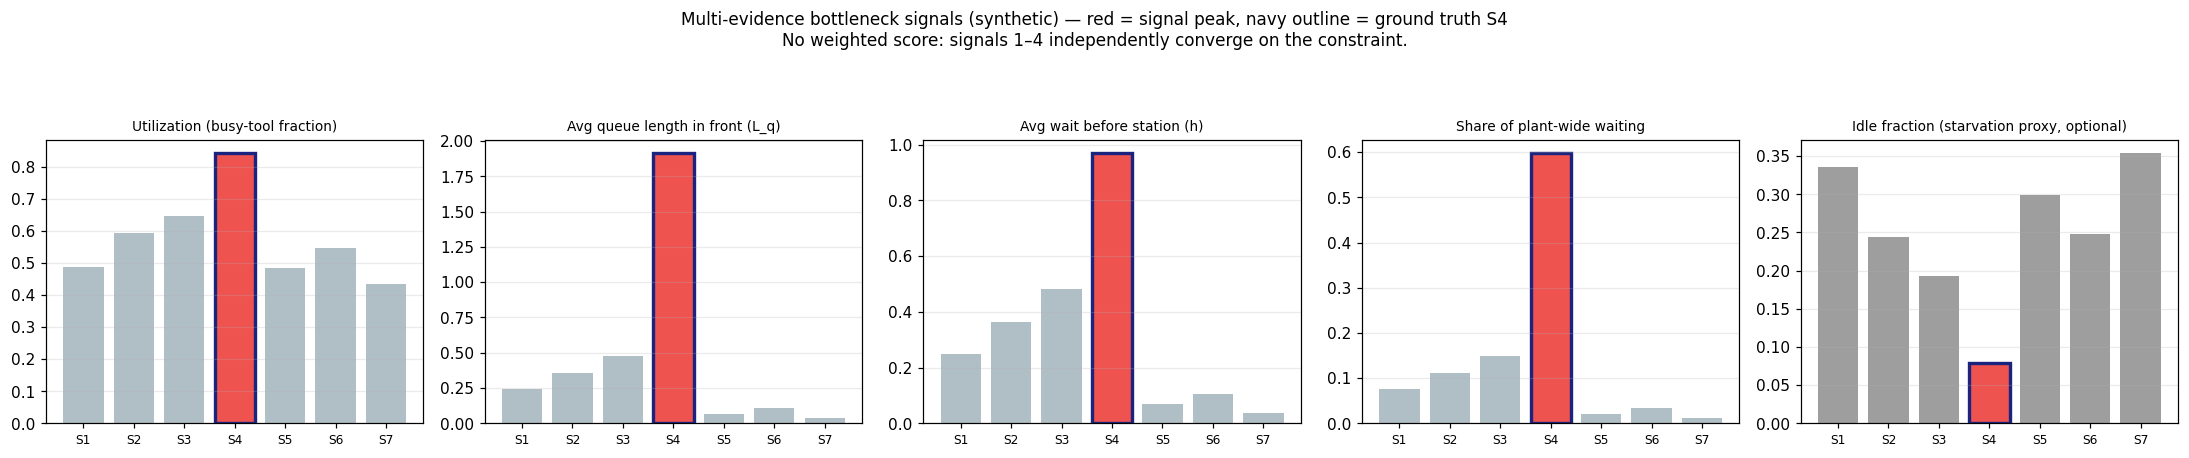

In [2]:
ev = evidence.station_evidence_synthetic(log, cfg, T0, T1)
display(ev.round(4))

print("Which station does each signal point to?")
for c in ["utilization", "avg_queue_len", "avg_wait_hours", "wait_share"]:
    print(f"  argmax {c:<16} -> {ev[c].idxmax()}")
print(f"  argmin idle_fraction (least starved) -> {ev['idle_fraction'].idxmin()}")
print(f"\nConverged station (majority of signals 1-4): {evidence.converged_station(ev)}")

evidence.plot_evidence_synthetic(ev, ground_truth='S4',
                                 save_path=str(FIG / 'bottleneck_evidence_synthetic.png'))
plt.show()

**Reading.** All four primary signals peak at **S4** and S4 is the *least* idle station.
Five independent views of the line agree without any tuned weights — the hallmark of a real
constraint rather than an artefact of one particular metric.

## Step 2 — Naive baselines mislead

Two heuristics people reach for first:

- **Naive-1 — highest frequency:** the most-visited station. Confuses *traffic* with constraint.
- **Naive-2 — longest processing time:** highest mean processing time per operation.
  Confuses *slow-per-op* with constraint; ignores tool count and visit frequency.

SYNTHETIC
  Naive-1 highest frequency  -> S4  (RIGHT, but only by coincidence: S4 is re-entrant so it has ~2x the operations)
  Naive-2 longest processing -> S3  (WRONG; the true constraint S4 is among the FASTEST per op at 0.85 h)
REAL 4TU
  Naive-1 highest frequency  -> Final Inspection Q.C.  (WRONG)
  Naive-2 longest processing -> Change Version - Machine 22  (8.2 h/op on only 4 ops — an obvious non-constraint)


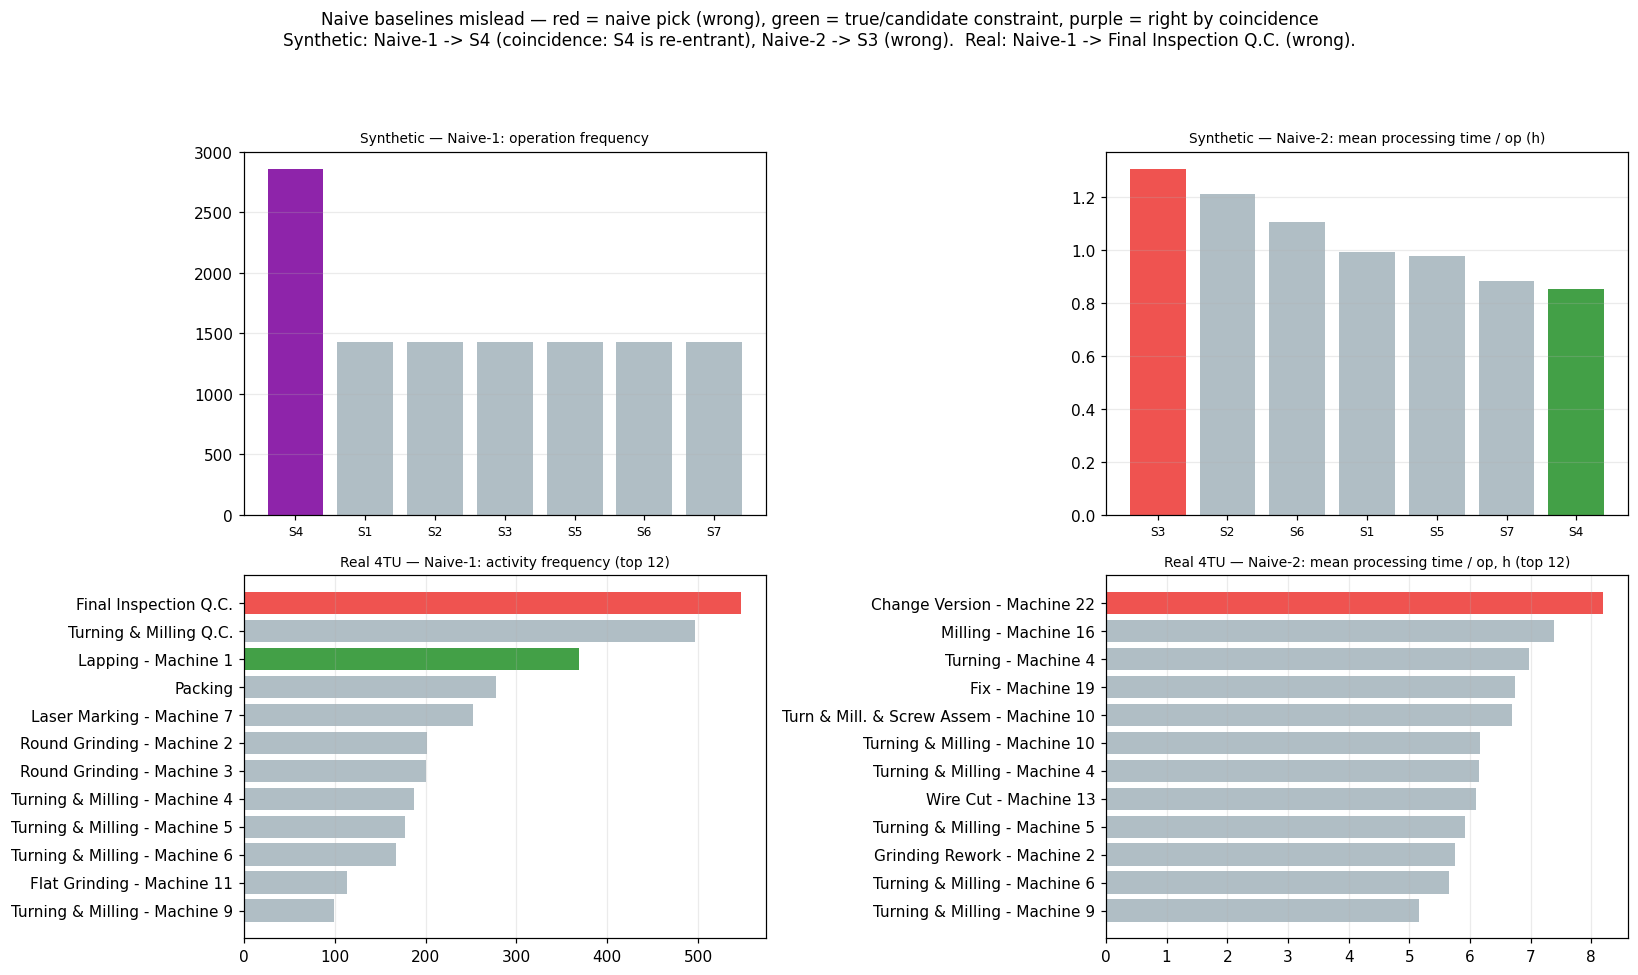

In [3]:
syn_table, syn_picks = naive_baselines.naive_baselines_synthetic(log, cfg)
real_table, real_picks = naive_baselines.naive_baselines_real(df_D)

print("SYNTHETIC")
print(f"  Naive-1 highest frequency  -> {syn_picks['highest_frequency']}  "
      f"(RIGHT, but only by coincidence: S4 is re-entrant so it has ~2x the operations)")
print(f"  Naive-2 longest processing -> {syn_picks['longest_processing']}  "
      f"(WRONG; the true constraint S4 is among the FASTEST per op at "
      f"{syn_table.loc['S4','mean_proc_hours']:.2f} h)")
print("REAL 4TU")
print(f"  Naive-1 highest frequency  -> {real_picks['highest_frequency']}  (WRONG)")
lp = real_picks['longest_processing']
print(f"  Naive-2 longest processing -> {lp}  "
      f"({real_table.loc[lp,'mean_proc_hours']:.1f} h/op on only "
      f"{int(real_table.loc[lp,'frequency'])} ops — an obvious non-constraint)")

real_ev = evidence.activity_evidence_real(df_D)
real_candidate = real_ev.index[0]
naive_baselines.plot_naive_baselines(syn_table, syn_picks, real_table, real_picks,
                                     syn_truth='S4', real_candidate=real_candidate,
                                     save_path=str(FIG / 'naive_baselines.png'))
plt.show()

**Conclusion.** A naive method that lands on the right station does so by *coincidence*,
not by principle — Naive-1 only works on the synthetic line because S4 happens to be
re-entrant, and it breaks immediately on the real log (it flags the high-traffic Final
Inspection Q.C.). Naive-2 is wrong on both. The constraint is only recovered reliably by the
queue/utilization evidence of Step 1.

## Step 3 — CRN counterfactual: quantify the decision, test the logic

We add **+1 tool** to a station and measure the paired improvement, for four scenarios:

- **baseline**, **S4 +1** (engineered constraint),
- **S3 +1** — *strict control*: 2nd-highest utilization and the station Naive-2 wrongly flags,
- **S7 +1** — *clean control*: low utilization, route-distant from S4.

**Common Random Numbers (CRN).** Each replication draws **one** random table (arrivals +
per-visit processing times); baseline and all three interventions run on that *same* table,
differing only in tool count. Every comparison is therefore a **paired** difference that
cancels simulation noise. First we prove CRN is actually in force — baseline vs baseline on
one table must give an **exact zero** delta (no hidden RNG escapes the table):

In [4]:
# CRN in force: baseline vs baseline on ONE shared draw table -> exact zero delta.
draws = draw_randoms(cfg, seed=cfg.seed)
log_b1, life_b1, _ = simulate(cfg, draws)
log_b2, life_b2, _ = simulate(cfg, draws)
k1 = counterfactual.steady_state_kpis(life_b1, T0, T1)
k2 = counterfactual.steady_state_kpis(life_b2, T0, T1)
print("CRN sanity — baseline vs baseline on the same table:")
print(f"  logs identical : {log_b1.equals(log_b2)}")
print(f"  Δthroughput    : {k2[0]-k1[0]:.3e}   (must be 0.0)")
print(f"  Δcycle_time    : {k2[1]-k1[1]:.3e}   (must be 0.0)")

CRN sanity — baseline vs baseline on the same table:
  logs identical : True
  Δthroughput    : 0.000e+00   (must be 0.0)
  Δcycle_time    : 0.000e+00   (must be 0.0)


Zero delta confirmed — the pairing is genuine. Now the counterfactual over
**N = 30** replications, reporting the paired **Δ mean + 95% CI**:

Δ cycle time (hours) — mean + 95% CI  [informative channel]


,n,mean,ci95_low,ci95_high,ci95_half
intervention,,,,,
S4+1,30,-2.3542,-2.6735,-2.0350,0.3192
S3+1,30,-0.1462,-0.1753,-0.1170,0.0292
S7+1,30,-0.0482,-0.0509,-0.0455,0.0027


Δ throughput (lots/hour) — mean + 95% CI


,n,mean,ci95_low,ci95_high,ci95_half
intervention,,,,,
S4+1,30,-0.000360,-0.001607,0.000887,0.001247
S3+1,30,-0.000129,-0.000500,0.000243,0.000371
S7+1,30,0.000000,-0.000076,0.000076,0.000076


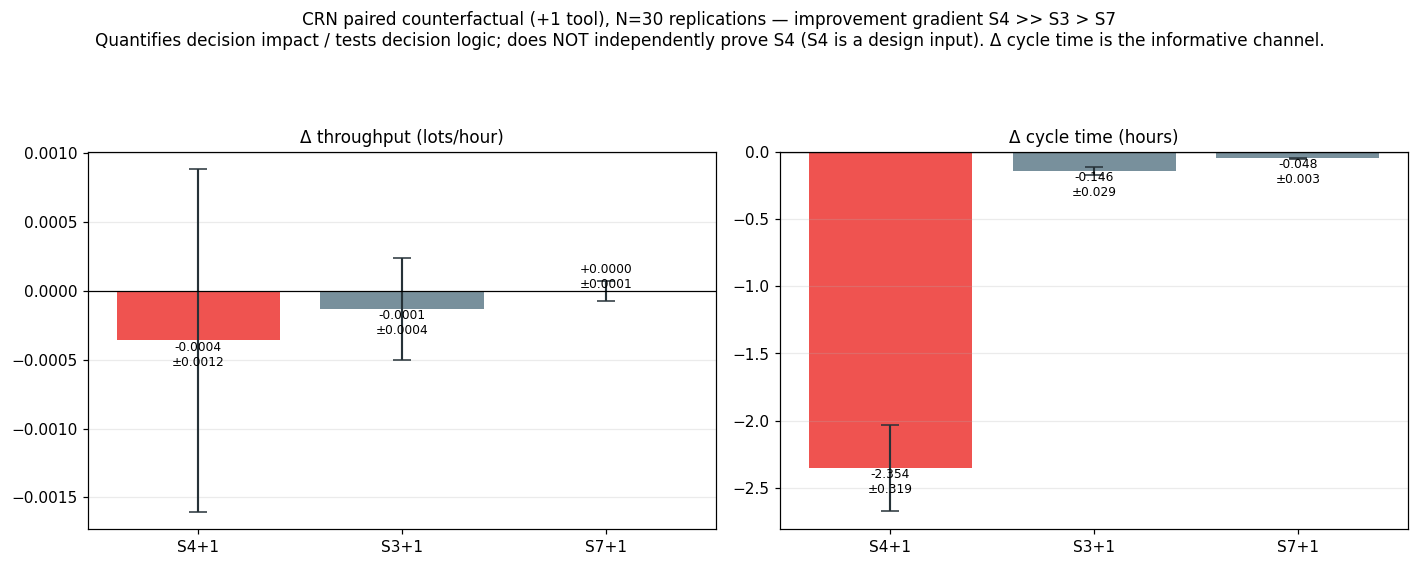

In [5]:
deltas = counterfactual.run_counterfactual(cfg, interventions=['S4','S3','S7'],
                                           n_reps=30, seed0=1000)
print("Δ cycle time (hours) — mean + 95% CI  [informative channel]")
display(counterfactual.summarize(deltas, 'd_cycle_time').round(4))
print("Δ throughput (lots/hour) — mean + 95% CI")
display(counterfactual.summarize(deltas, 'd_throughput').round(6))

counterfactual.plot_counterfactual(deltas, save_path=str(FIG / 'counterfactual_capacity.png'))
plt.show()

**Reading.** Relieving **S4** cuts cycle time by ~**2.35 h**, roughly **16x** the strict
control S3 and **~49x** the clean control S7, with tight non-overlapping CIs — the exact
gradient a correct bottleneck call predicts.

Two honest notes:
- **Δ throughput ≈ 0 for every station.** The line is a *stable open network* (every ρ < 1),
  so in steady state throughput is set by the arrival rate (Little's Law): capacity relief
  shows up in **cycle time / WIP**, not throughput. Cycle time is the informative channel here.
- This step **quantifies the decision impact** of a capacity change and **tests the decision
  logic**. It does **not** independently prove S4 is the bottleneck — S4 is a design input;
  we already know the answer and are checking the method reproduces it.

## Step 4 — Ground-truth validation

Two independent lines of evidence, on data whose answer we designed in advance:

In [6]:
print("Ground-truth bottleneck (design input)      : S4")
print("Step 1 evidence convergence picks           :", evidence.converged_station(ev))
best = counterfactual.summarize(deltas, 'd_cycle_time')['mean'].idxmin()  # most negative
print("Step 3 largest cycle-time improvement (+1)  :", best)
print()
print("Both point to S4 => the method recovers the engineered constraint.")

Ground-truth bottleneck (design input)      : S4
Step 1 evidence convergence picks           : S4
Step 3 largest cycle-time improvement (+1)  : S4+1

Both point to S4 => the method recovers the engineered constraint.


Evidence convergence (Step 1) and the counterfactual gradient (Step 3) **both** indict the
station we engineered as the constraint. The method is validated on ground truth, so we can
apply it to real data with a calibrated sense of what it does and does not show.

## Step 5 — Apply to the real 4TU production log

We run the **same evidence-convergence idea** on the real log — but only the **queue-based**
signals are available, and this must be stated plainly:

- **Utilization is NOT computable.** The real log has no declared tool counts, no arrival
  model, and an irregular calendar (nights/weekends idle). A defensible utilization cannot be
  derived, so we do not fabricate one.
- **No counterfactual is possible.** The real line cannot be re-simulated — there is no route
  plan, capacity, or arrival process to perturb. We can only name a **candidate** by evidence
  convergence, not quantify a capacity change.

Waiting time is the gap between a step's start and the previous step's completion within a
case, attributed to the *receiving* step (same convention as notebook 01, Section 6).

,n_ops,total_wait_hours,wait_share,median_wait_hours,total_proc_hours,wait_proc_ratio
Activity,,,,,,
Lapping - Machine 1,369,20401.150,0.209,2.117,656.033,31.098
Final Inspection Q.C.,547,15318.667,0.157,7.217,1046.983,14.631
Turning & Milling Q.C.,496,11441.733,0.117,1.808,754.817,15.158
Laser Marking - Machine 7,252,9183.250,0.094,4.025,242.600,37.853
Packing,277,8230.367,0.085,9.983,277.000,29.713
Grinding Rework - Machine 27,69,5309.283,0.055,13.500,180.617,29.395
Round Grinding - Machine 2,202,3321.283,0.034,0.983,897.450,3.701
Round Grinding - Machine 3,201,3234.983,0.033,0.958,890.317,3.634
Grinding Rework - Machine 12,11,2457.500,0.025,9.967,22.500,109.222


argmax total_wait_hours : Lapping - Machine 1
argmax wait_share       : Lapping - Machine 1

Candidate bottleneck (convergence of total waiting + wait share): Lapping - Machine 1


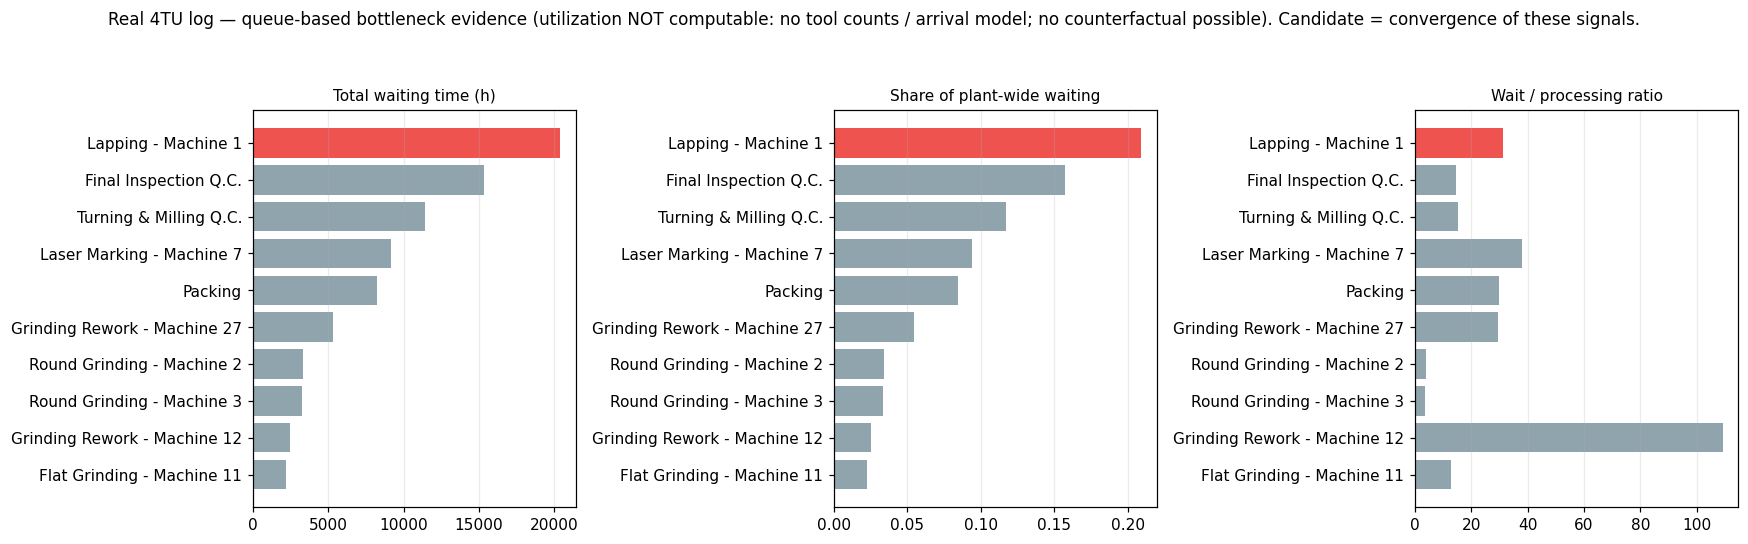

In [7]:
real_ev = evidence.activity_evidence_real(df_D)
display(real_ev.head(10).round(3))

print("argmax total_wait_hours :", real_ev['total_wait_hours'].idxmax())
print("argmax wait_share       :", real_ev['wait_share'].idxmax())
cand = real_ev.index[0]
print("\nCandidate bottleneck (convergence of total waiting + wait share):", cand)

evidence.plot_evidence_real(real_ev, top_n=10, candidate=cand,
                            save_path=str(FIG / 'bottleneck_evidence_real.png'))
plt.show()

**Reading.** Total waiting time and share-of-plant-waiting both converge on
**Lapping - Machine 1** (~20,400 h of accumulated waiting, ~21% of all plant waiting) → named
as the **candidate** bottleneck. Note this is **not** the highest-traffic activity (Final
Inspection Q.C.) — exactly the station the naive frequency baseline wrongly flags in Step 2.
The wait/processing ratio is noisier (its top is a tiny-n Grinding Rework outlier) and is
treated as secondary evidence.

**Honest limit.** On the real log this is a *candidate identified by descriptive convergence*,
not a validated constraint: without capacities or an arrival model we cannot compute
utilization or run the counterfactual that we used to validate the method on synthetic data.

## Summary

| Step | Output |
|---|---|
| 1 Multi-evidence (synthetic) | utilization, queue length, wait, wait-share, starvation all converge on **S4** (no weighted score) |
| 2 Naive baselines | highest-frequency → S4 *by coincidence* / Final QC (real, wrong); longest-processing → S3 (wrong) |
| 3 CRN counterfactual | Δcycle_time S4 −2.35 h ≫ S3 −0.15 h > S7 −0.05 h (N=30, 95% CI); Δthroughput ≈ 0 (arrival-limited) |
| 4 Validation | evidence + counterfactual both recover the engineered constraint **S4** |
| 5 Real 4TU log | candidate **Lapping - Machine 1** by queue-based convergence; utilization & counterfactual not computable |

**Figures (`reports/figures/`):** `bottleneck_evidence_synthetic.png`, `naive_baselines.png`,
`counterfactual_capacity.png`, `bottleneck_evidence_real.png`.

**Method integrity:** every signal is a transparent queueing/utilization quantity; there is no
black-box model and no weighted index. The counterfactual is a paired CRN experiment that
quantifies decision impact and tests decision logic, not a proof of a known design input. On
real data, the honest boundary — evidence-based candidate only — is stated explicitly.